In [13]:
!git clone https://github.com/<author>/drify.git
%cd drify
!pip install -e .

/bin/bash: line 1: author: No such file or directory
[Errno 2] No such file or directory: 'drify'
/content
Obtaining file:///content
ERROR: file:///content does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [14]:
!pip install brian2

In [16]:
from brian2 import *
import matplotlib.pyplot as plt

In [17]:
start_scope()
defaultclock.dt = 1*ms

In [18]:
eqs = '''
dv/dt = (-v + I_total)/tau_soma : 1
dexc/dt = -exc/tau_exc : 1        # dendritic excitability
I_total : 1
tau_soma : second
tau_exc : second
'''

In [19]:
neuron = NeuronGroup(
    1,
    eqs,
    threshold='v > (0.7 - exc)',   # adaptive threshold
    reset='v = 0; exc = 0',
    method='euler'
)

neuron.v = 0
neuron.exc = 0
neuron.tau_soma = 20*ms
neuron.tau_exc = 20*ms

In [20]:
# Distal (context) arrives first
distal = SpikeGeneratorGroup(
    1, indices=[0], times=[8]*ms
)

# Proximal (sensory) arrives shortly after
proximal = SpikeGeneratorGroup(
    1, indices=[0], times=[10]*ms
)

In [21]:
distal_syn = Synapses(
    distal, neuron,
    '''
    w : 1
    ''',
    on_pre='''
    exc += 1.2*w               # raises excitability
    I_total += 0.2 * w     # attenuated signal
    '''
)

distal_syn.connect()
distal_syn.w = 0.4

In [22]:
proximal_syn = Synapses(
    proximal, neuron,
    '''
    w : 1
    ''',
    on_pre='''
    I_total += 0.8 * w
    '''
)

proximal_syn.connect()
proximal_syn.w = 0.6

In [23]:
stdp = Synapses(
    distal, neuron,
    '''
    w : 1
    dapre/dt = -apre/20/ms : 1 (event-driven)
    dapost/dt = -apost/20/ms : 1 (event-driven)
    ''',
    on_pre='''
    apre += 1
    w += apost * 0.01
    ''',
    on_post='''
    apost += 1
    w += apre * 0.01
    '''
)

stdp.connect()
stdp.w = 0.4

In [24]:
Vmon = StateMonitor(neuron, ['v', 'exc'], record=True)
Spikemon = SpikeMonitor(neuron)

In [25]:
run(30*ms)

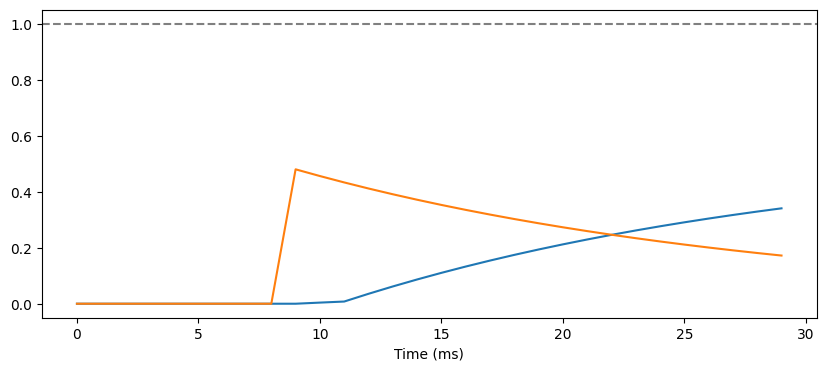

In [27]:
plt.figure(figsize=(10,4))
plt.plot(Vmon.t/ms, Vmon.v[0], label='Soma voltage')
plt.plot(Vmon.t/ms, Vmon.exc[0], label='Excitability')
plt.axhline(1, linestyle='--', color='gray', label='Base threshold')
plt.scatter(Spikemon.t/ms, [1.1]*len(Spikemon.t), color='red', label='Soma spike')
plt.xlabel('Time (ms)')
plt.show()